# PLA-ChAT object analysis: a visual, reproducible walkthrough

This notebook analyzes the four HALO Object Colocalization FL exports in this repository. It is deliberately descriptive: the object rows are measurements nested within image regions, not independent animals or biological replicates.

The central visual is an **object-derived spatial reconstruction**. It uses the midpoint of each exported bounding box and overlays PLA-derived heat maps on a grayscale map of ChAT object counts. The original OME-TIFF is not included, so this is not a recovered microscopy image, tissue mask, cell segmentation, or pixelwise fluorescence overlay. Add the original image and its OME metadata before making a true image overlay or physical-scale figure.

## How to read the figures

- **Counts** show exported detections per coordinate bin; they are not tissue density without an analyzed-area mask.
- **PLA with ChAT present** is a PLA-object fraction. Empty bins and bins below the support threshold are not the same thing as zero association.
- **Mean overlap** averages each PLA object's reported overlap percentage. **Area-weighted overlap** gives larger objects more influence.
- Every spatial position is a bounding-box midpoint in uncalibrated export coordinate units. Y is displayed in the exported orientation.
- The notebook retains zero diameters, zero-width boxes, and other review features. It does not silently filter them.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd

# Find the repository even when Jupyter was launched from a subdirectory.
HERE = Path.cwd().resolve()
REPO = next((p for p in [HERE, *HERE.parents] if (p / 'bio_visuals').is_dir() and (p / 'abstract.txt').is_file()), HERE)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from bio_visuals.data import load_data, summarize, quality_control, top_objects
from bio_visuals.plots import (
    setup_style, overview, ecdf_figures, overlap_composition, size_overlap,
    area_sensitivity, measurement_qc, area_concentration,
)
from bio_visuals.spatial import coordinate_overview, spatial_atlas, region_heatmap, bounding_box_zoom
from bio_visuals.reporting import save_figure, export_tables, write_run_metadata

setup_style()
plt.rcParams['figure.constrained_layout.use'] = False
print(f'Repository: {REPO}')

Matplotlib is building the font cache; this may take a moment.


Repository: /Users/adambrewer/Desktop/Coding/Bio_Data_Analysis


In [2]:
# Analysis controls. These are display choices, not biological cutoffs.
DATA_ROOT = REPO
OUTPUT_ROOT = REPO / 'outputs'
SPATIAL_BIN_WIDTH = 250       # exported coordinate units
MIN_PLA_SUPPORT = 10          # raw PLA objects required for fraction colors
SPATIAL_SMOOTHING = 0         # Gaussian sigma in bins; 0 keeps maps unsmoothed
FOCUS_JOB = '4595'             # selected region for the detailed overlay
FOCUS_WINDOW = 150             # exported coordinate units for box close-up

objects, manifest = load_data(DATA_ROOT, verify_hashes=True)
print(f'{len(objects):,} object rows loaded from {len(manifest)} exports')
display(manifest[['job', 'region', 'rows', 'bytes', 'sha256']])

1,078,756 object rows loaded from 4 exports


,job,region,rows,bytes,sha256
0,4594,22M_Pfkp-TDP43 PLA,186343,61368709,83839e1e12719dd022d1e594a8effec80ba1059bcb3af2...
1,4595,24M_Pfkp-TDP43 PLA,297584,98212792,8013fb5553aebe4457dccfa42d13f52bb5497f186df544...
2,4596,22M_Hk1-TDP43 PLA,238084,78610195,e1a16aada3ad0f589395f5567c64571d3a98c87d377187...
3,4597,24M_Hk1-TDP43 PLA,356745,118022846,47a953163ff19d35e2c34ba3f483a9b38035b3dda29eb2...


## 1. Audit the exports before interpreting them

The object type is the primary denominator decision. A PLA-present flag can occur on a ChAT row, so counting the flag alone would mix object populations.

In [3]:
summary = summarize(objects)
qc = quality_control(objects)
pla_summary = summary[summary.object_type == 'PLA'].copy()
display(pla_summary[['job', 'region', 'n_objects', 'other_marker_count', 'other_marker_pct', 'mean_object_overlap_pct', 'area_weighted_overlap_pct']])
display(qc[['job', 'n_objects', 'overlap_pct_formula_mismatch', 'overlap_presence_mismatch', 'any_zero_diameter', 'zero_bbox_width_or_height']])

,job,region,n_objects,other_marker_count,other_marker_pct,mean_object_overlap_pct,area_weighted_overlap_pct
1,4594,22M_Pfkp-TDP43 PLA,9112,5380,59.043020,46.263292,43.077723
3,4595,24M_Pfkp-TDP43 PLA,7999,5512,68.908614,55.838135,45.243235
5,4596,22M_Hk1-TDP43 PLA,15282,6485,42.435545,30.644042,38.020494
7,4597,24M_Hk1-TDP43 PLA,43918,24355,55.455622,45.150685,43.509257


,job,n_objects,overlap_pct_formula_mismatch,overlap_presence_mismatch,any_zero_diameter,zero_bbox_width_or_height
0,4594,186343,0,0,2556,2383
1,4595,297584,0,0,2416,1980
2,4596,238084,0,0,4180,4045
3,4597,356745,0,0,14362,13001


## 2. Overview: counts and three overlap denominators

The third panel is intentionally a denominator check. These quantities answer different questions and should not be collapsed into one generic ‘colocalization’ percentage.

,job,region,label,pla_objects,chat_objects,pla_with_chat,pla_without_chat,pla_object_fraction_pct,pla_mean_overlap_pct,pla_area_weighted_overlap_pct
0,4594,22M_Pfkp-TDP43 PLA,22M · Pfkp-TDP43,9112,177231,5380,3732,59.043020,46.263292,43.077723
1,4595,24M_Pfkp-TDP43 PLA,24M · Pfkp-TDP43,7999,289585,5512,2487,68.908614,55.838135,45.243235
2,4596,22M_Hk1-TDP43 PLA,22M · Hk1-TDP43,15282,222802,6485,8797,42.435545,30.644042,38.020494
3,4597,24M_Hk1-TDP43 PLA,24M · Hk1-TDP43,43918,312827,24355,19563,55.455622,45.150685,43.509257


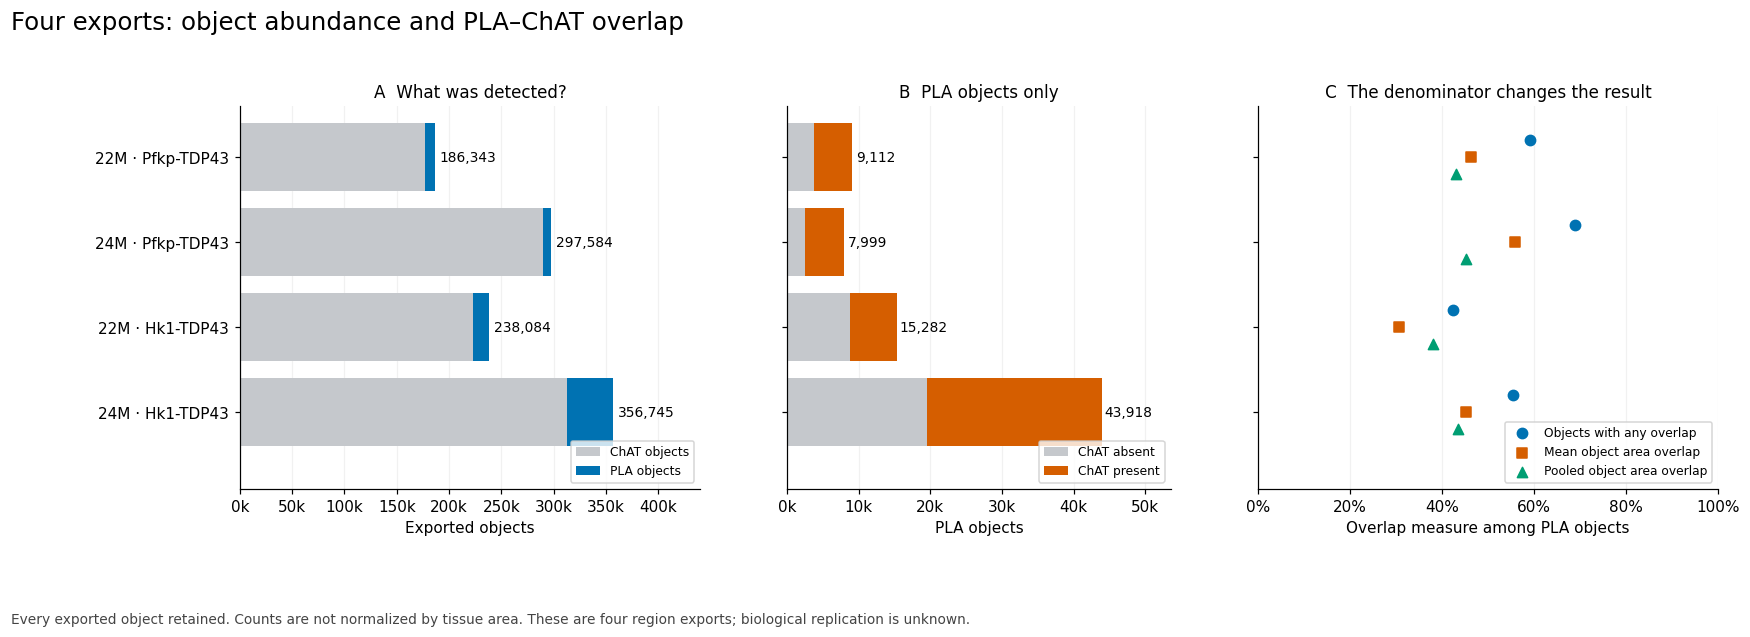

[PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/figures/01_overview_denominators.png'),
 PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/figures/01_overview_denominators.pdf')]

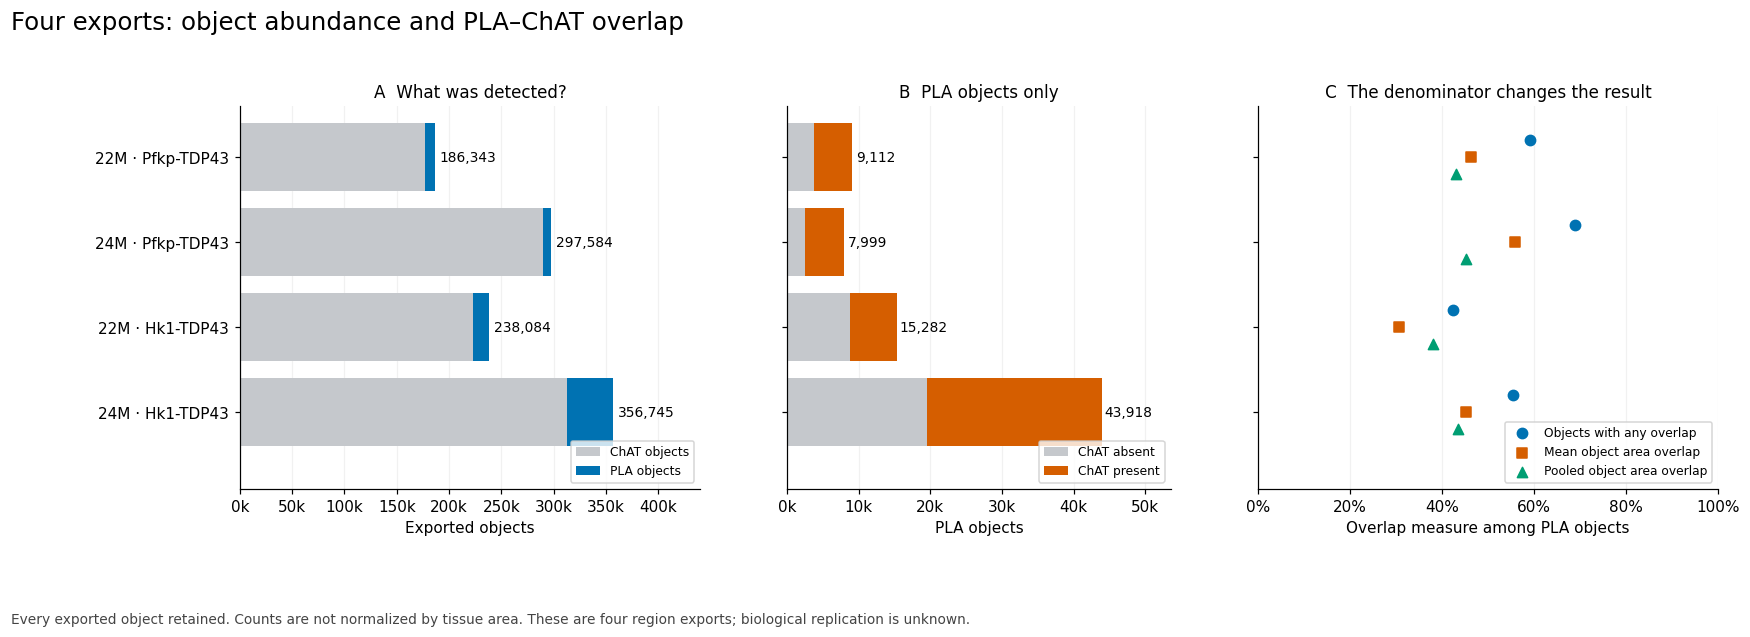

In [4]:
fig_overview, overview_table = overview(objects)
display(overview_table)
display(fig_overview)
save_figure(fig_overview, '01_overview_denominators', OUTPUT_ROOT)

## 3. Reconstructed spatial atlas

The left figure combines ChAT object-count background with PLA count heat. The next figures use the same coordinate bins to show where the ChAT-associated PLA fraction and mean object overlap are supported by enough PLA objects.

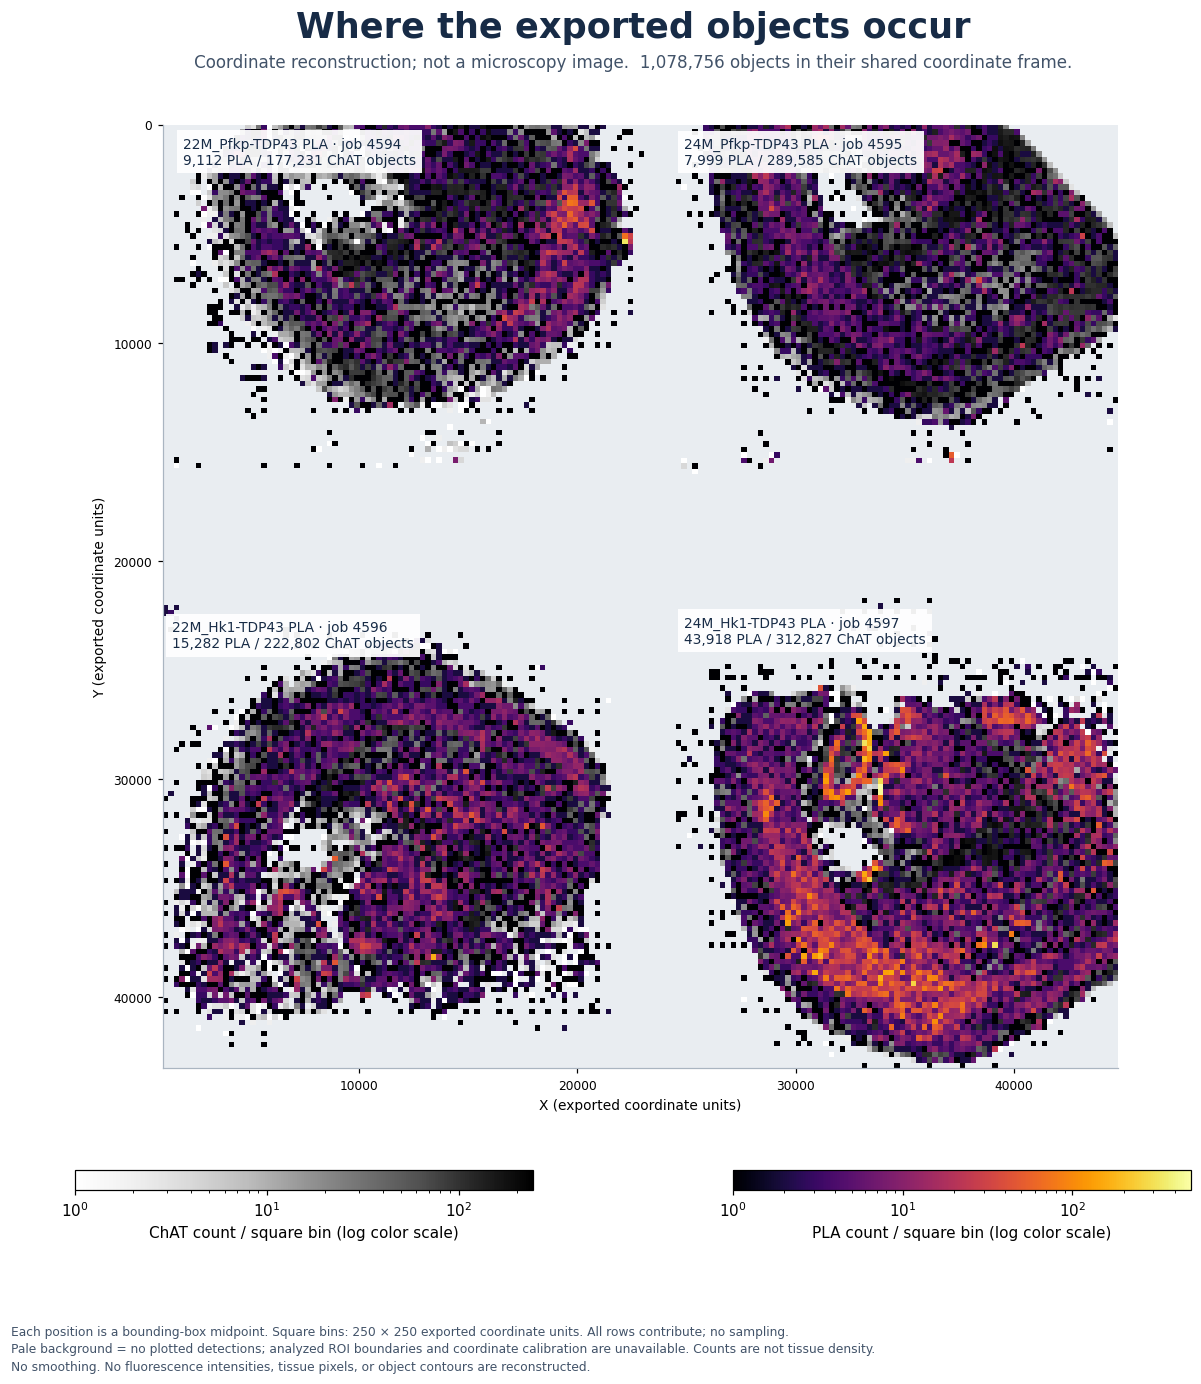

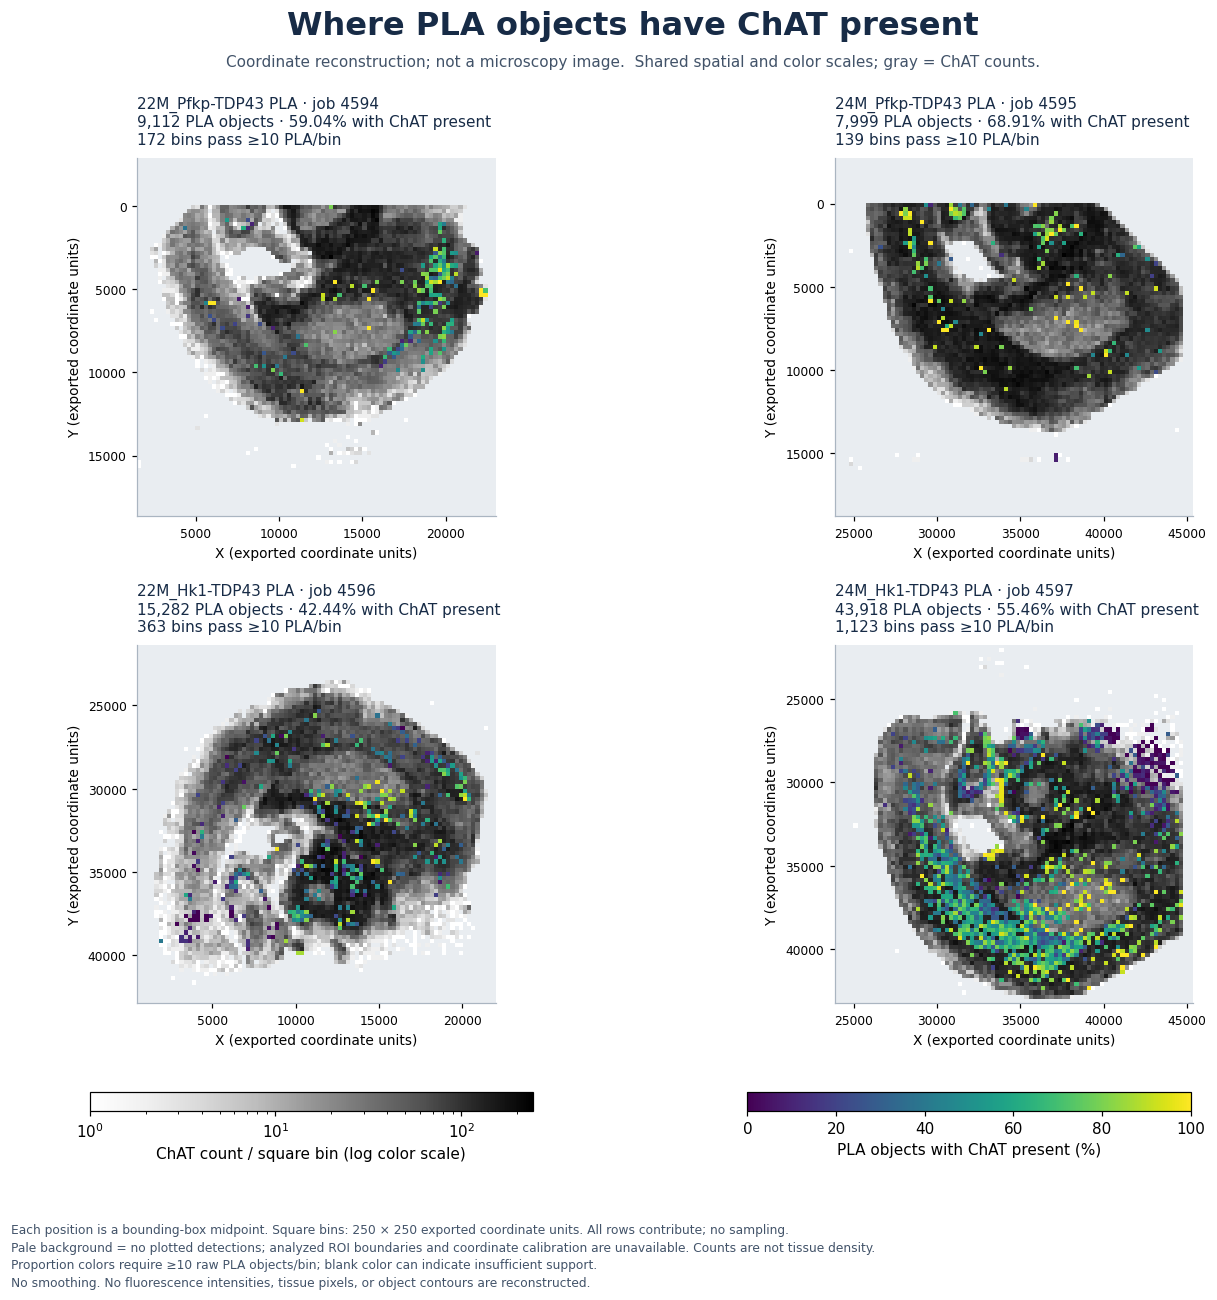

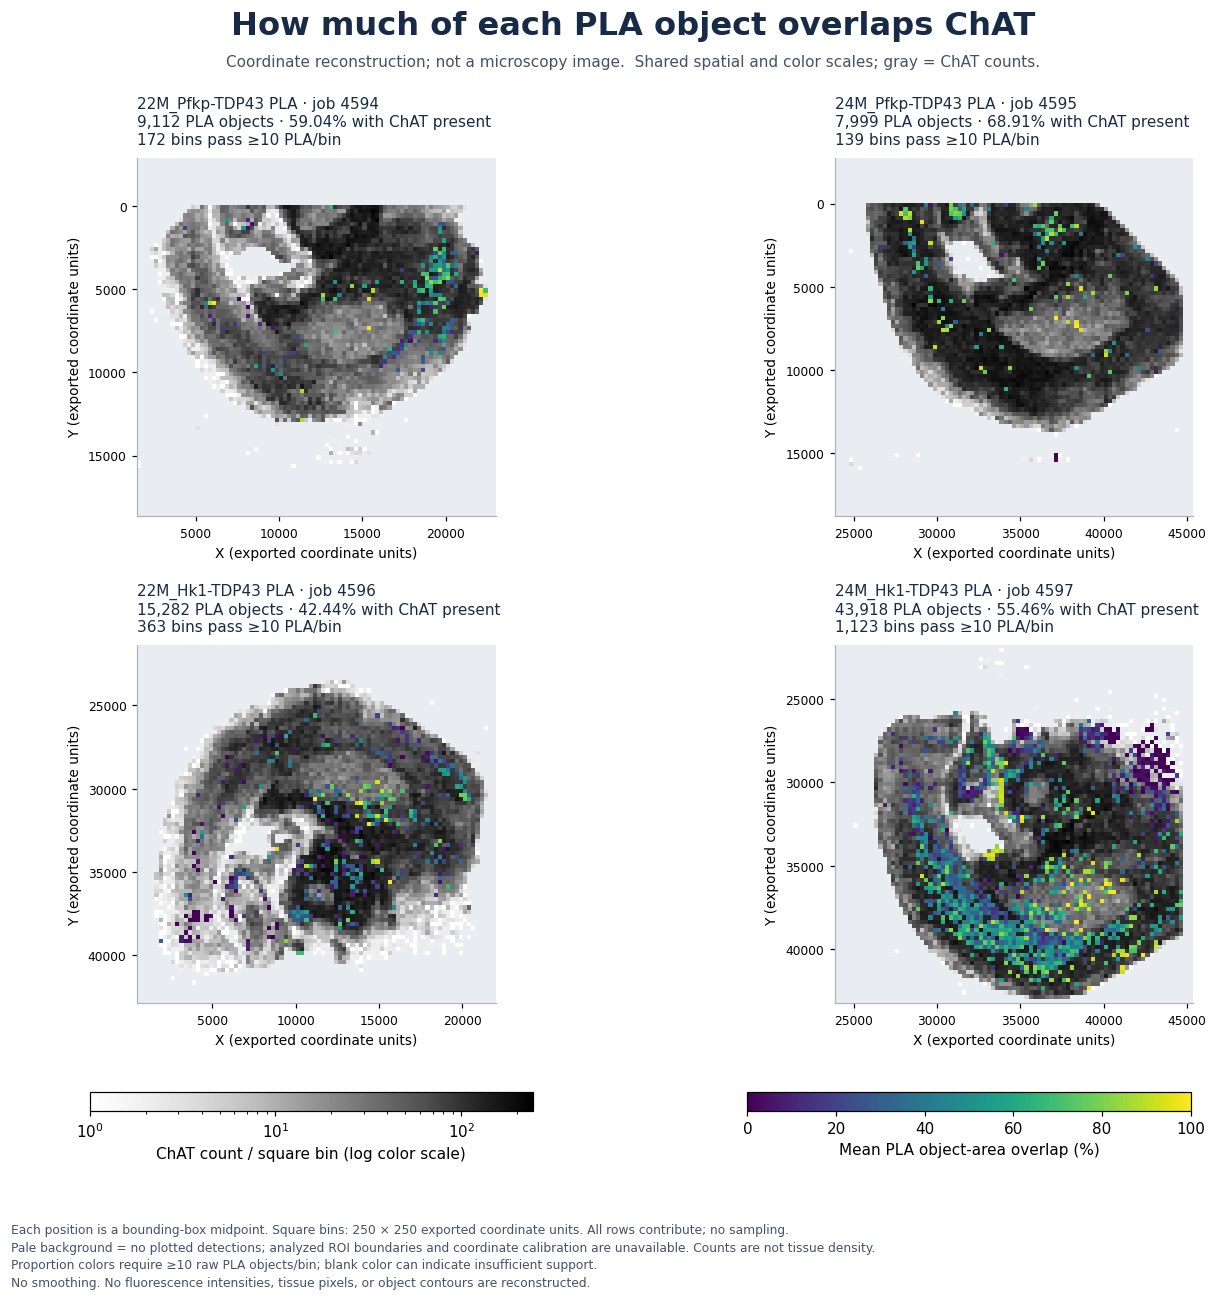

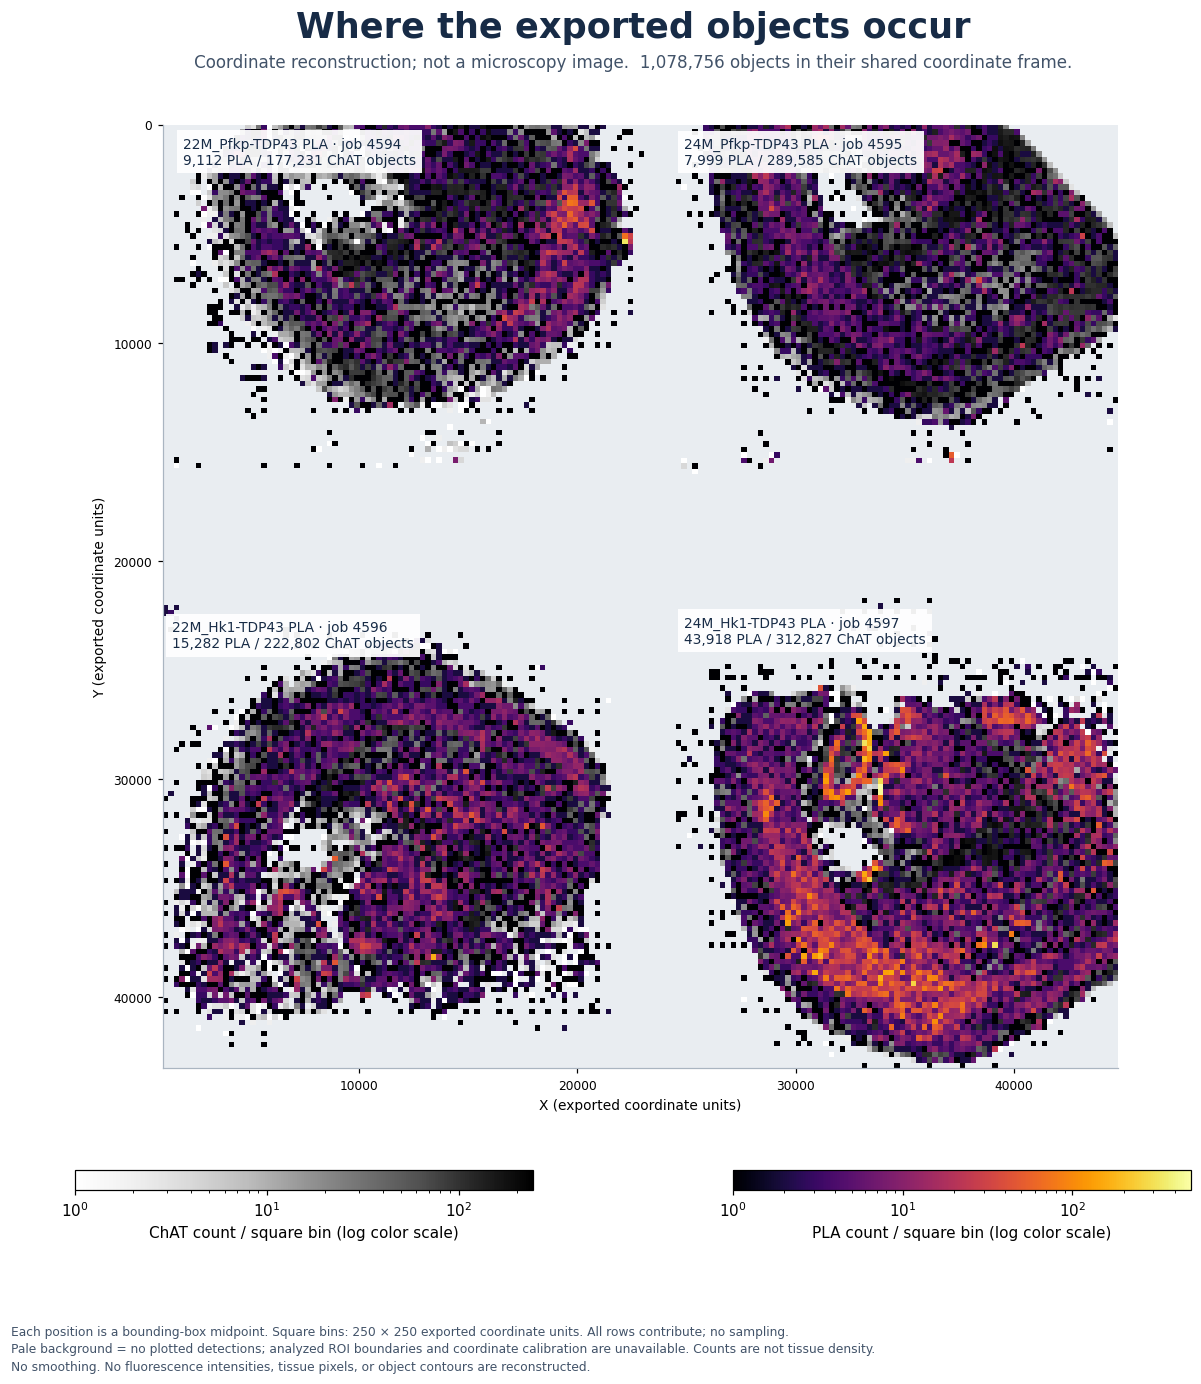

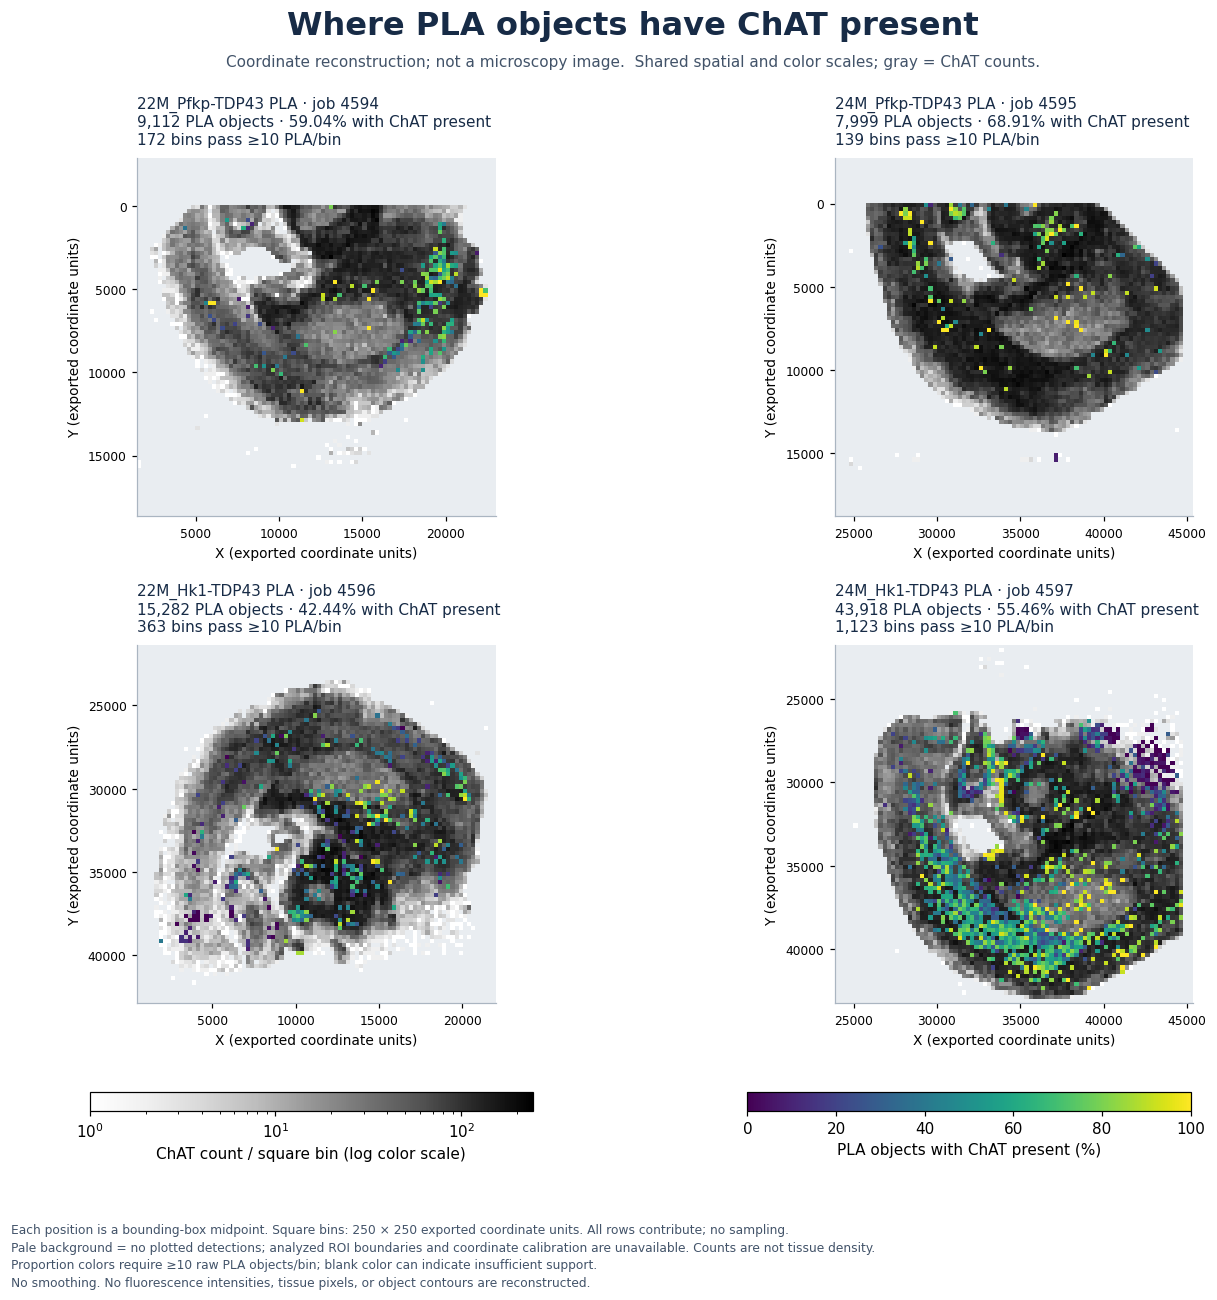

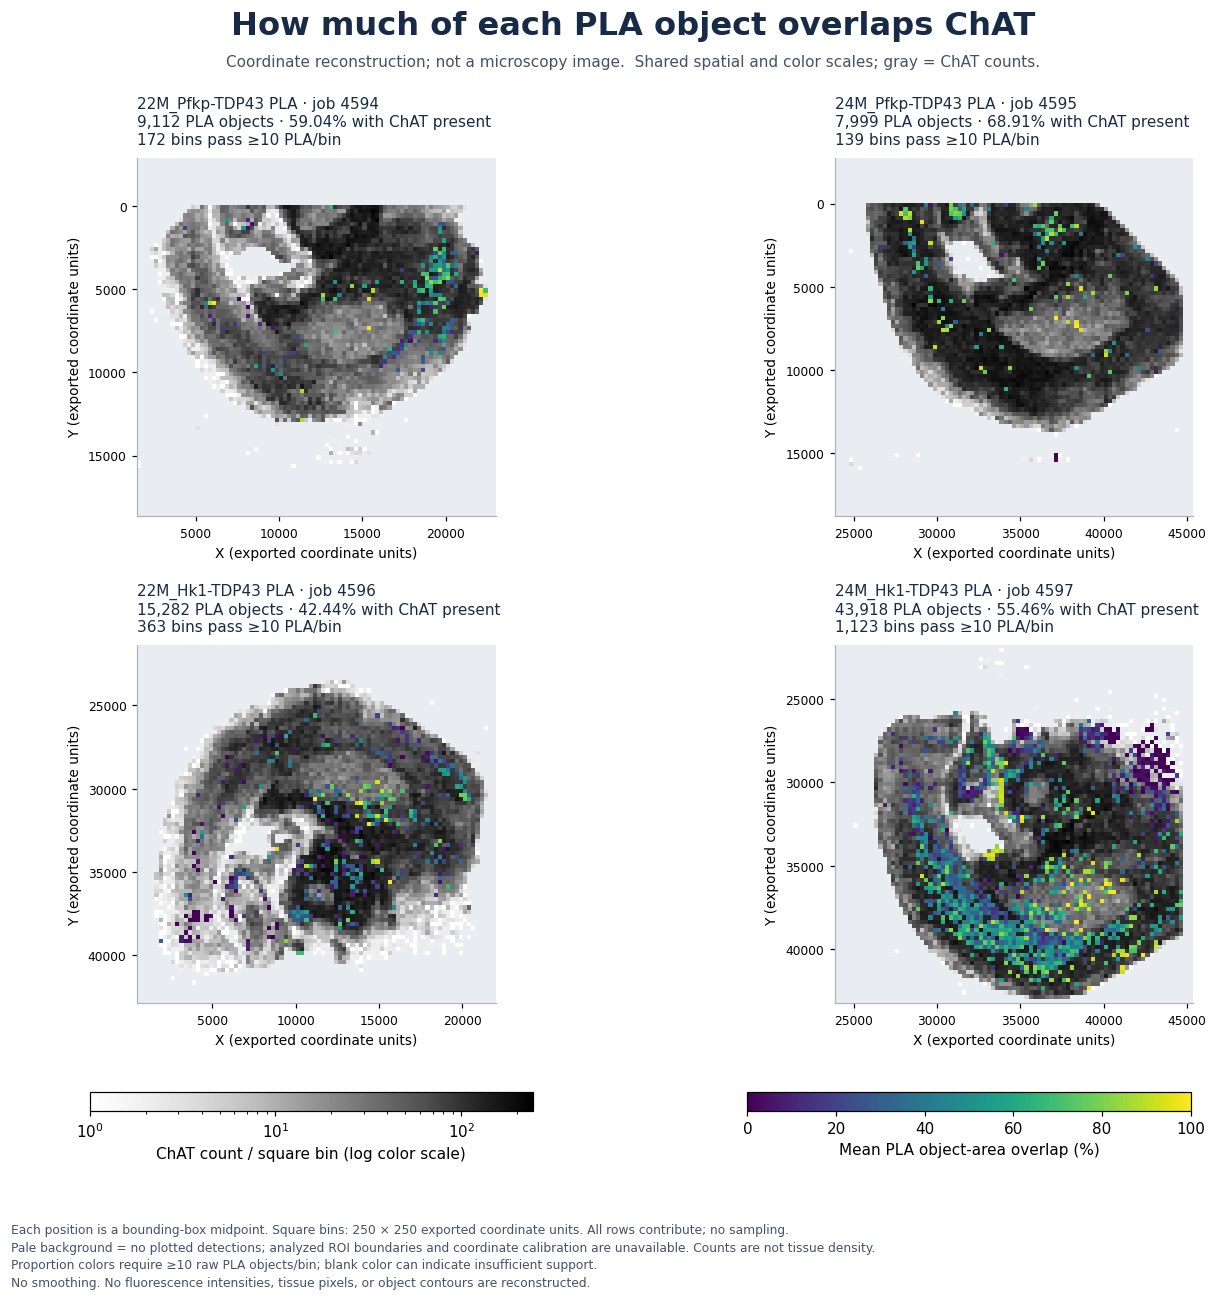

In [5]:
fig_atlas, atlas_table = coordinate_overview(objects, bin_width=SPATIAL_BIN_WIDTH)
display(fig_atlas)
save_figure(fig_atlas, '02_coordinate_reconstruction_PLA_on_ChAT', OUTPUT_ROOT)

spatial_tables = {'coordinate_overview': atlas_table}
for metric, name in [('pla_fraction', '03_heatmap_PLA_fraction_with_ChAT'), ('mean_overlap', '04_heatmap_mean_PLA_overlap')]:
    fig, table = spatial_atlas(objects, metric=metric, bin_width=SPATIAL_BIN_WIDTH, min_support=MIN_PLA_SUPPORT, smoothing=SPATIAL_SMOOTHING)
    display(fig)
    save_figure(fig, name, OUTPUT_ROOT)
    spatial_tables[metric + '_atlas'] = table

## 4. Detailed overlay for one region

This is the closest possible image-like view from the supplied tables: a selected PLA-derived metric over a grayscale ChAT-count layer, paired with its raw PLA denominator. Hatching marks nonempty bins that do not meet the support threshold.

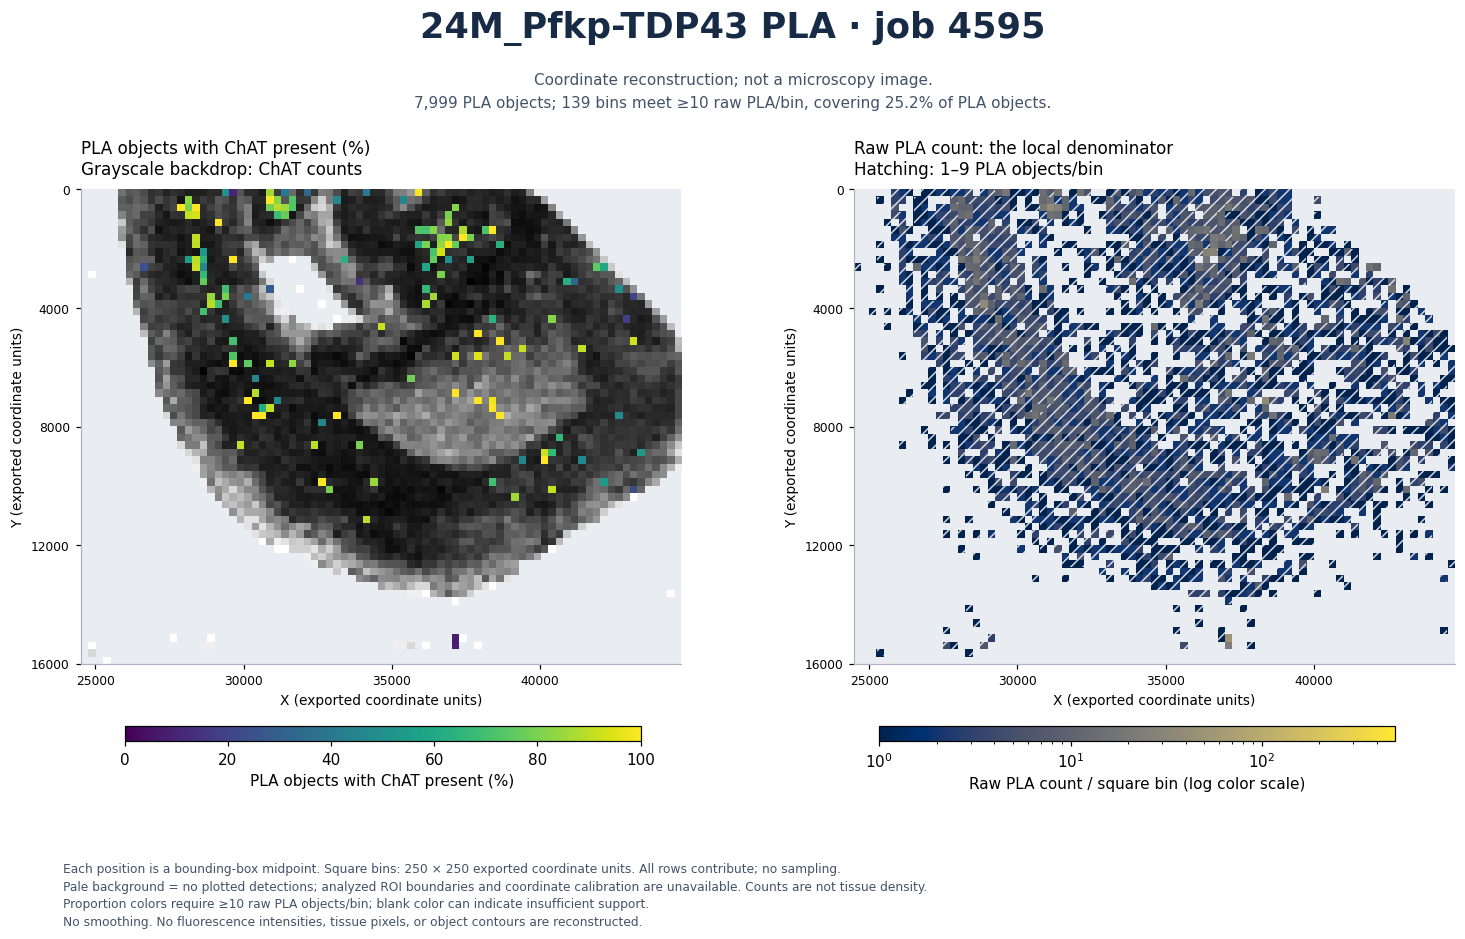

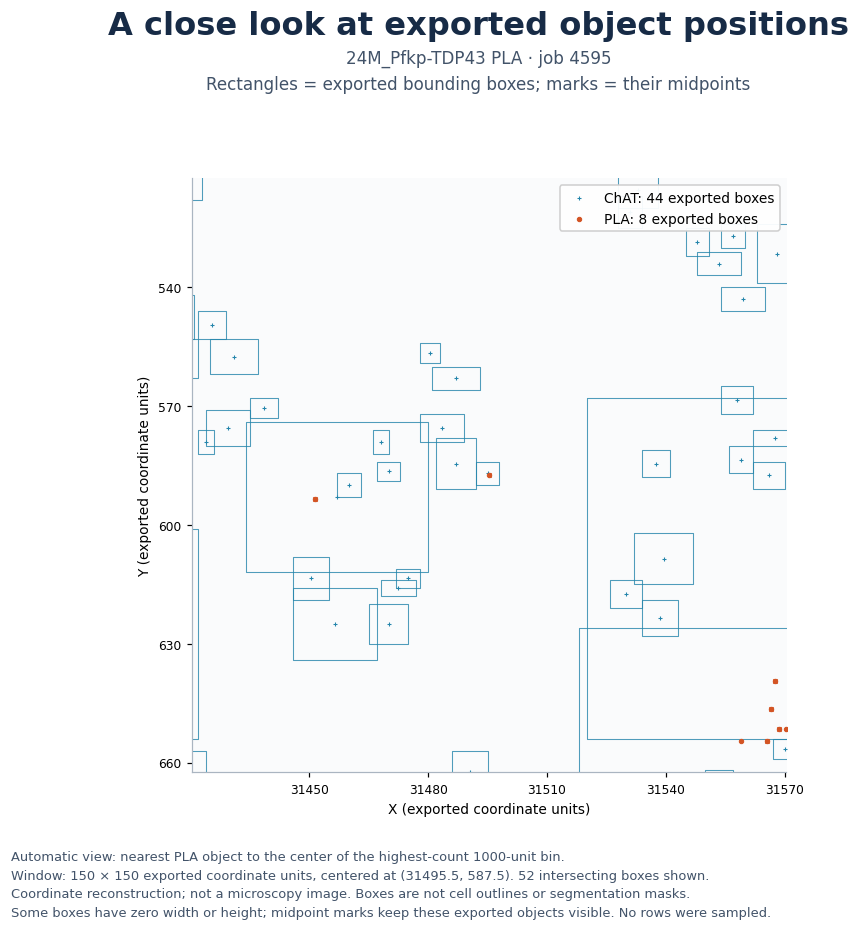

[PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/figures/06_exported_bounding_boxes_job_4595.png'),
 PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/figures/06_exported_bounding_boxes_job_4595.pdf')]

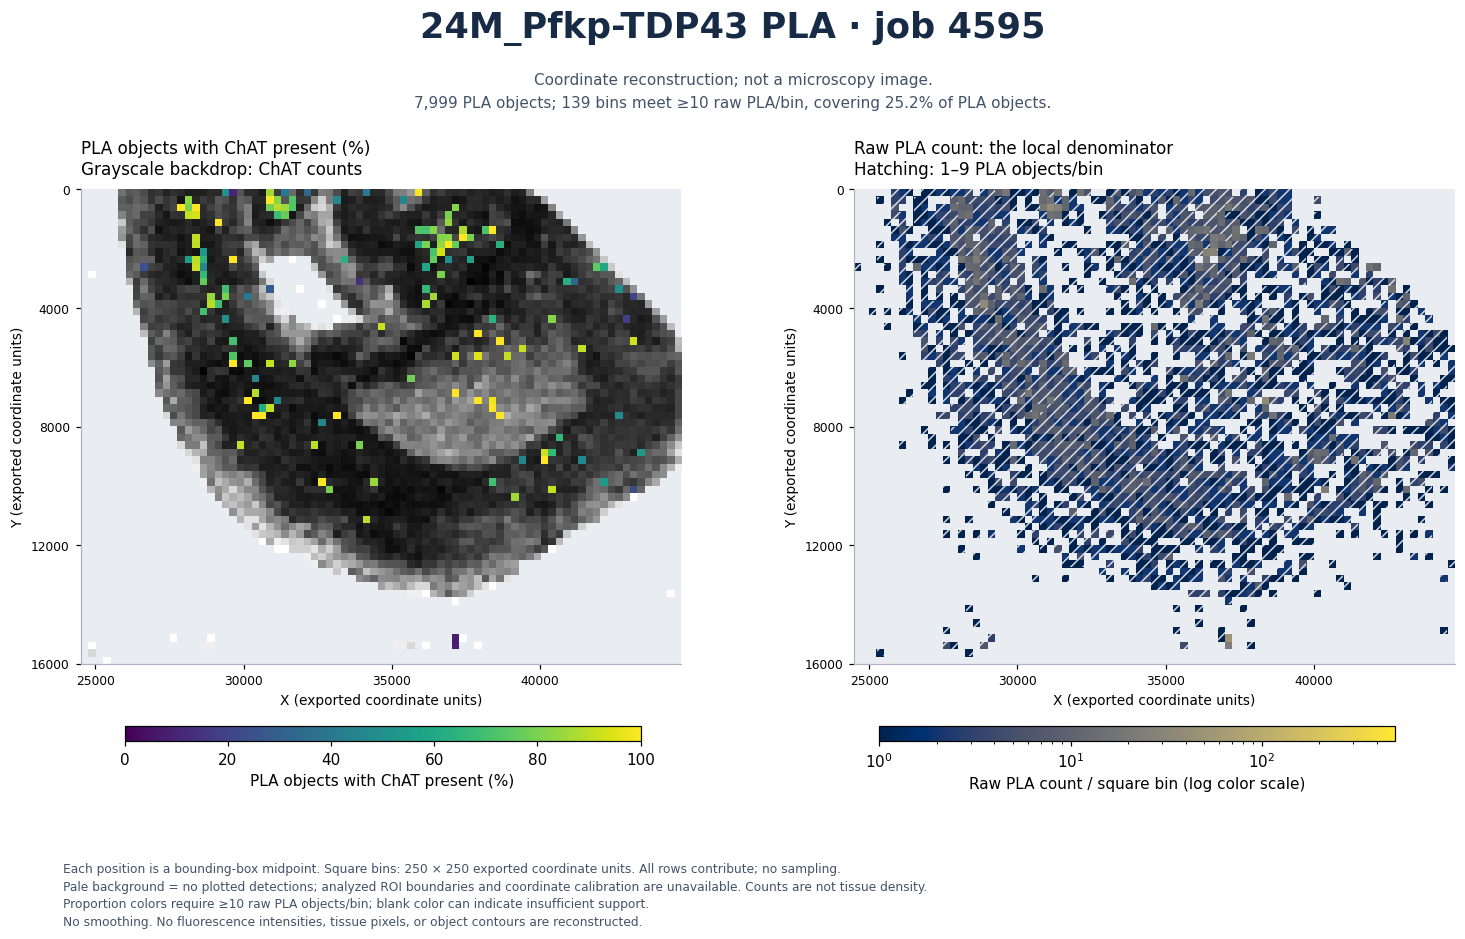

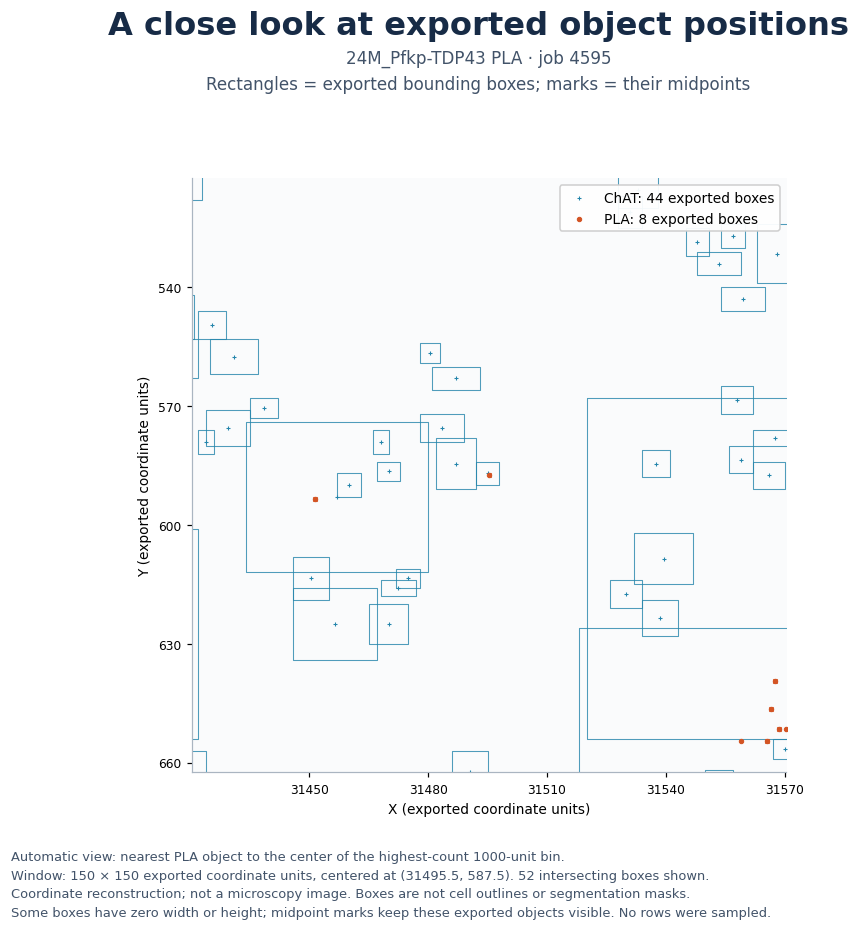

In [6]:
fig_focus, focus_table = region_heatmap(objects, FOCUS_JOB, metric='pla_fraction', bin_width=SPATIAL_BIN_WIDTH, min_support=MIN_PLA_SUPPORT, smoothing=SPATIAL_SMOOTHING)
display(fig_focus)
save_figure(fig_focus, f'05_detailed_overlay_job_{FOCUS_JOB}', OUTPUT_ROOT)
spatial_tables['focus_region_fraction'] = focus_table

fig_boxes = bounding_box_zoom(objects, FOCUS_JOB, window=FOCUS_WINDOW)
display(fig_boxes)
save_figure(fig_boxes, f'06_exported_bounding_boxes_job_{FOCUS_JOB}', OUTPUT_ROOT)

## 5. Full distributions and object-level structure

ECDFs preserve the whole distribution and ties. The overlap composition keeps exact 0% and 100% endpoint masses visible. Hexbin-style 2D summaries avoid plotting more than a million points as an unreadable scatter cloud.

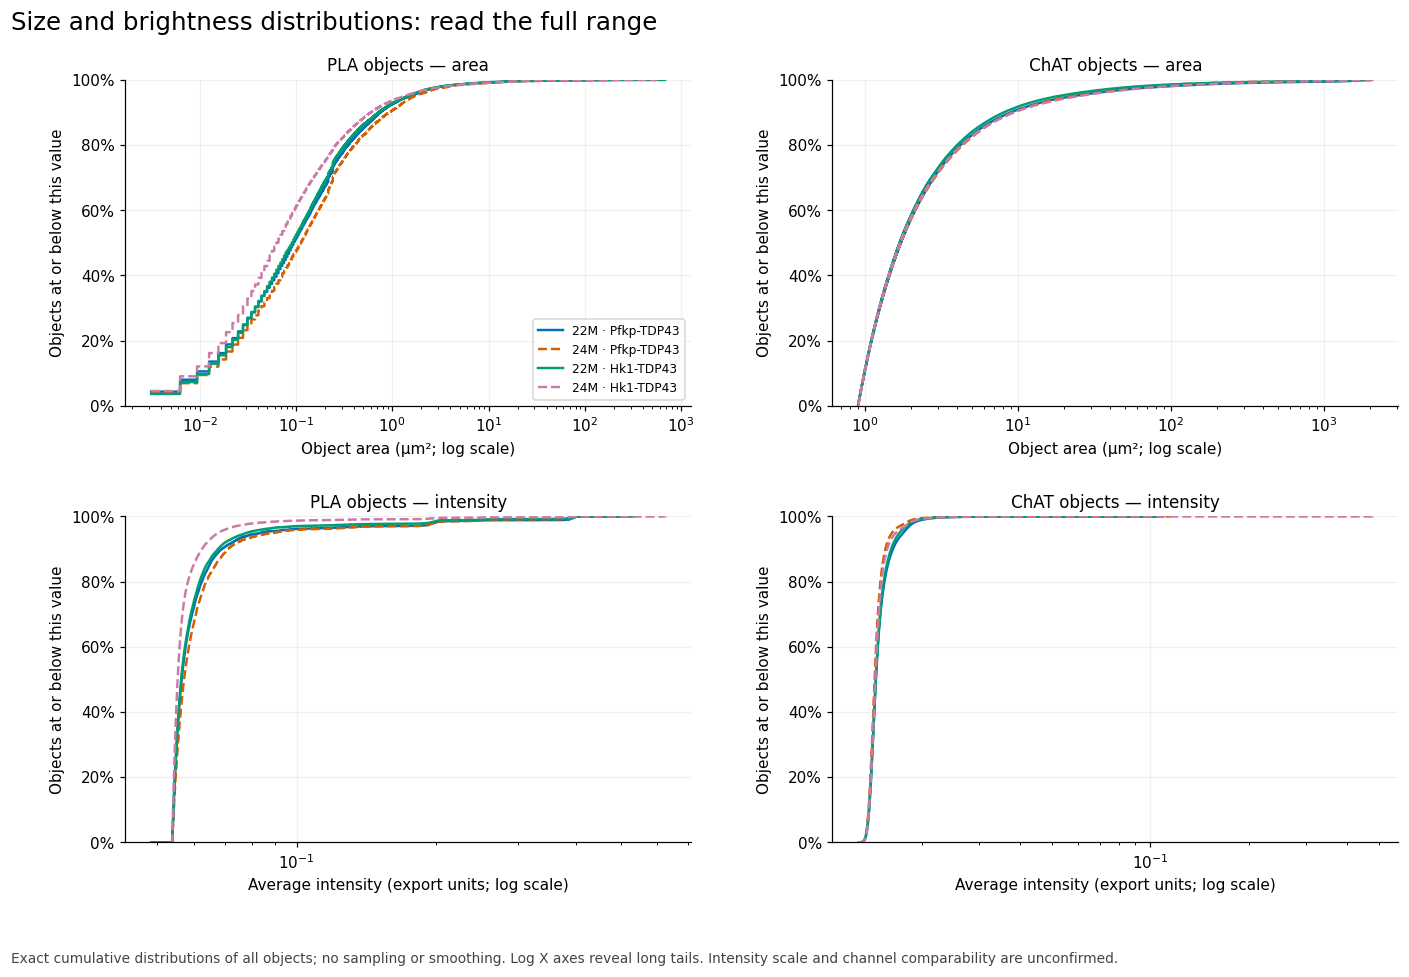

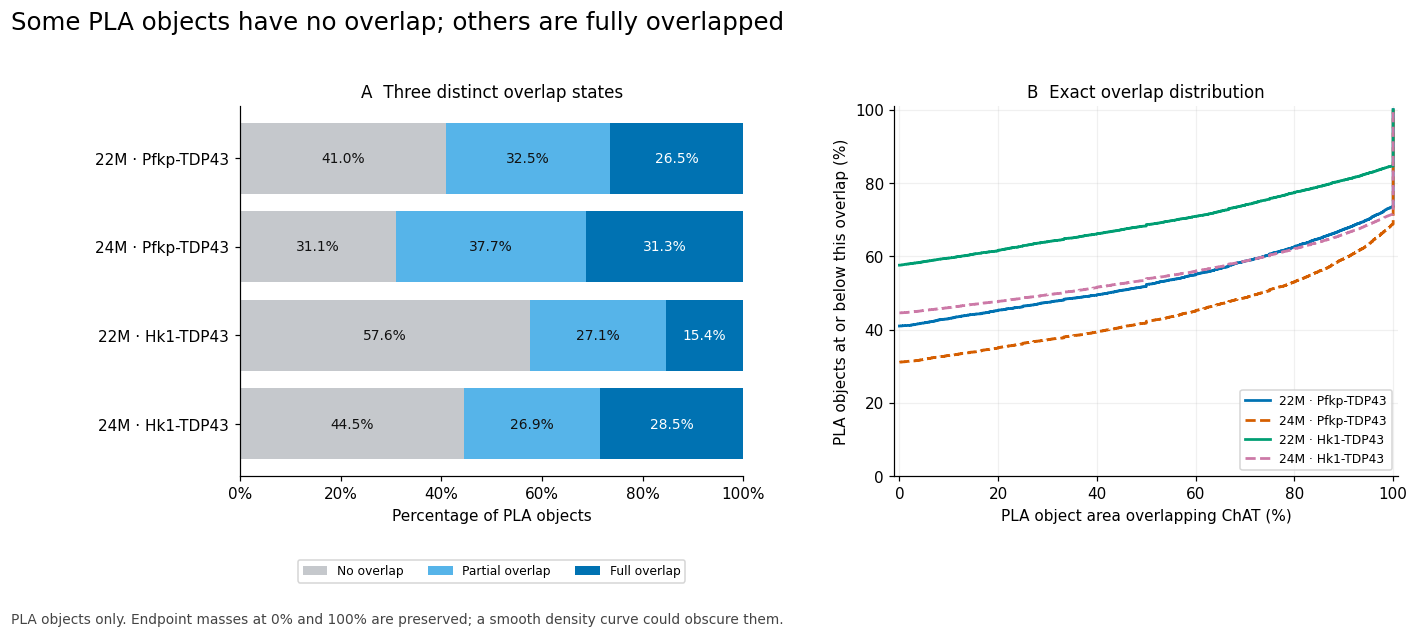

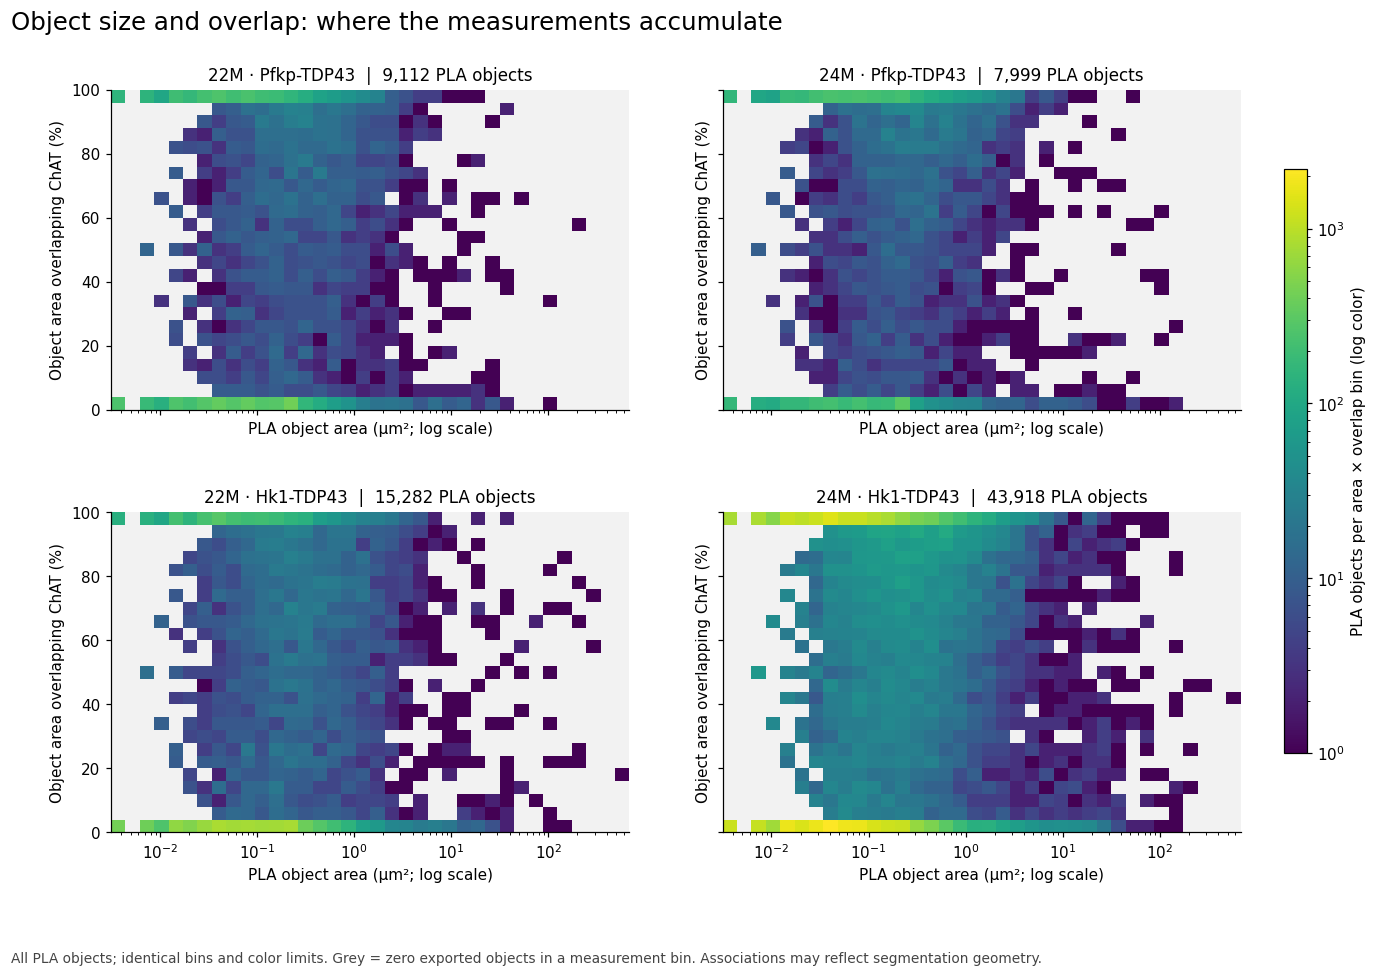

[PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/figures/09_size_by_overlap_hexbin.png'),
 PosixPath('/Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/figures/09_size_by_overlap_hexbin.pdf')]

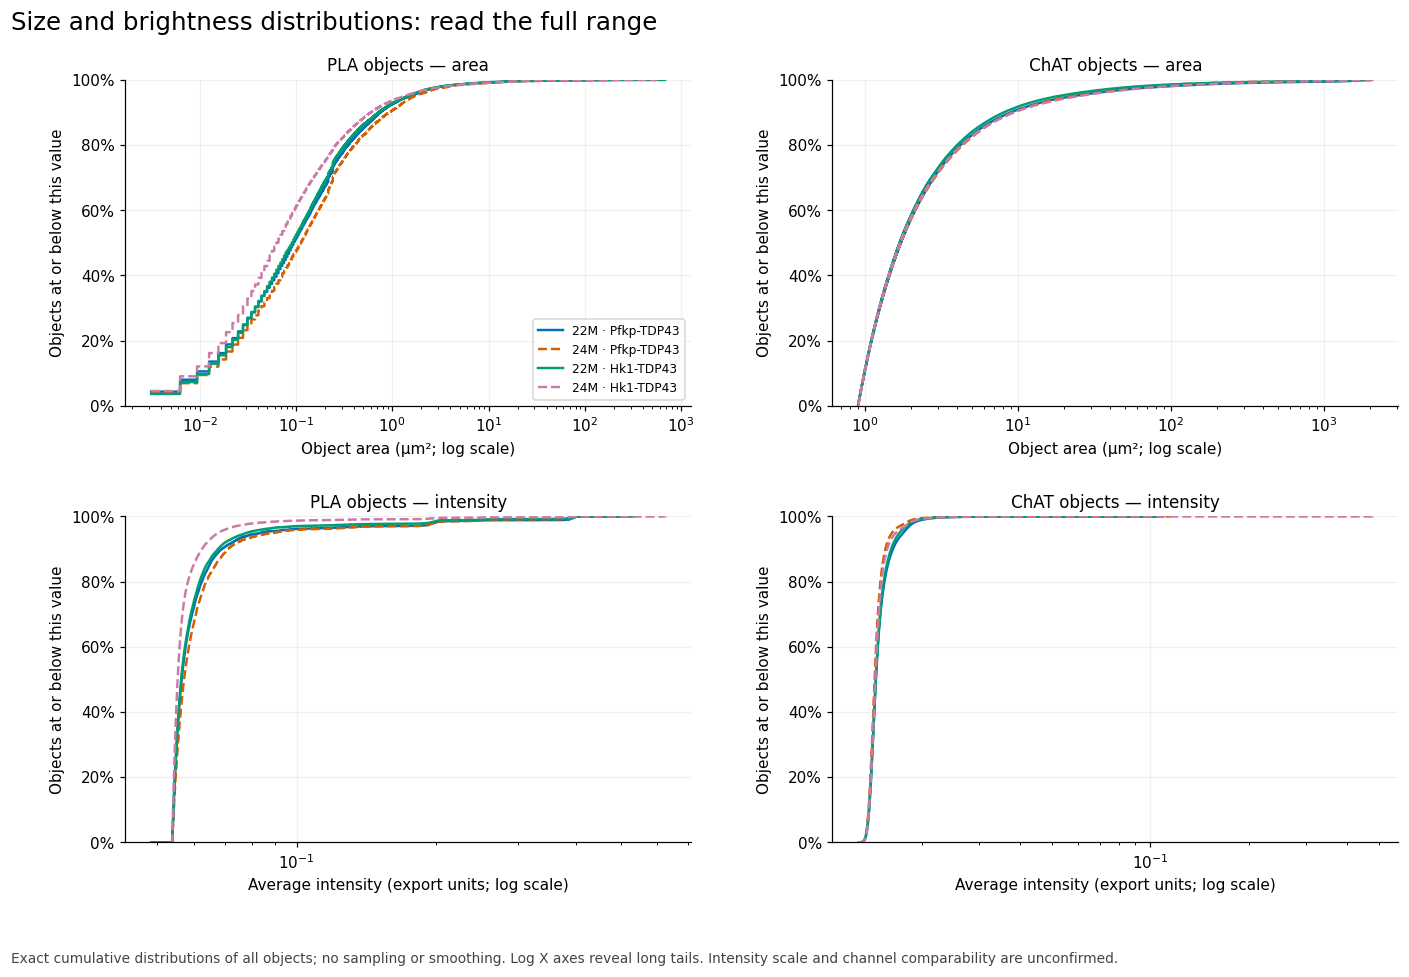

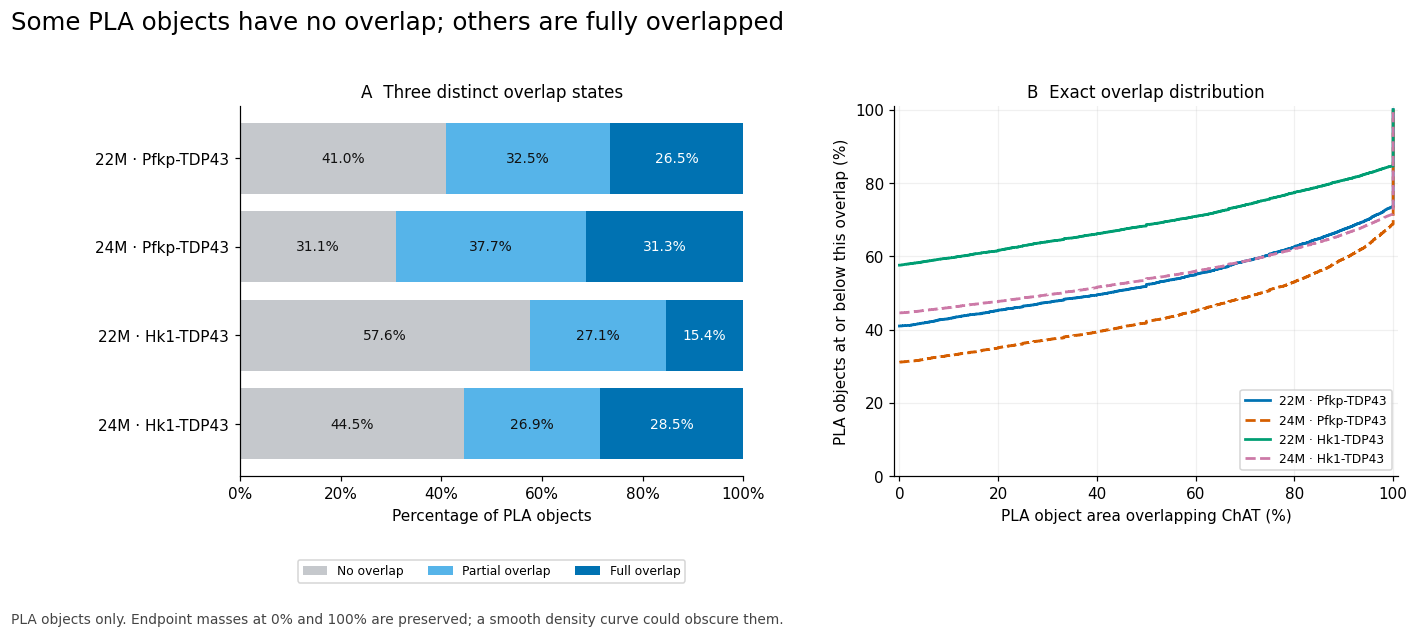

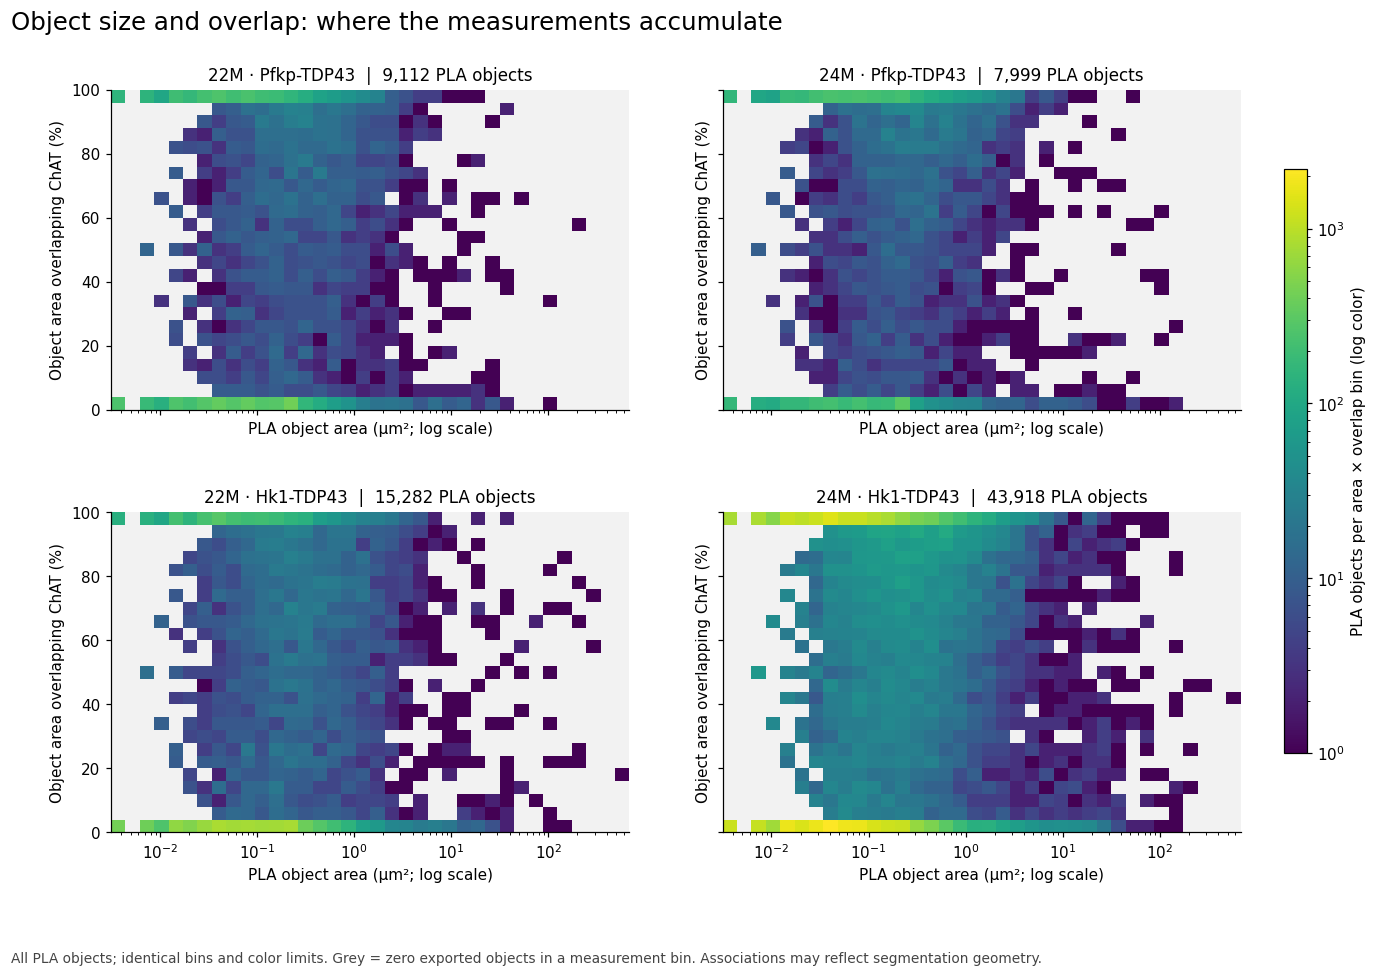

In [7]:
fig_ecdf, ecdf_table = ecdf_figures(objects)
display(fig_ecdf)
save_figure(fig_ecdf, '07_size_and_intensity_ecdfs', OUTPUT_ROOT)

fig_overlap, overlap_table = overlap_composition(objects)
display(fig_overlap)
save_figure(fig_overlap, '08_overlap_composition', OUTPUT_ROOT)

fig_size_overlap, size_overlap_table = size_overlap(objects)
display(fig_size_overlap)
save_figure(fig_size_overlap, '09_size_by_overlap_hexbin', OUTPUT_ROOT)

## 6. Quality review and sensitivity analysis

These views are prompts for image and parameter review, not automatic artifact calls. Area-threshold curves show how an eventual size filter could change the result; they do not select a cutoff.

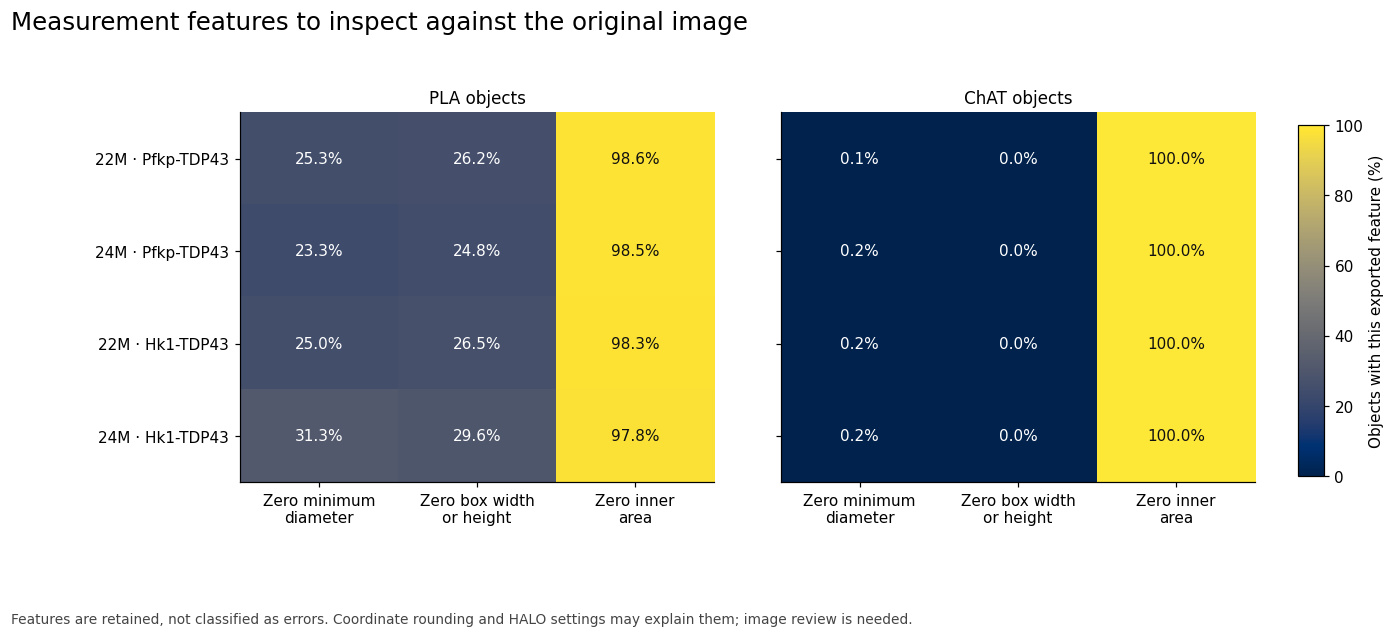

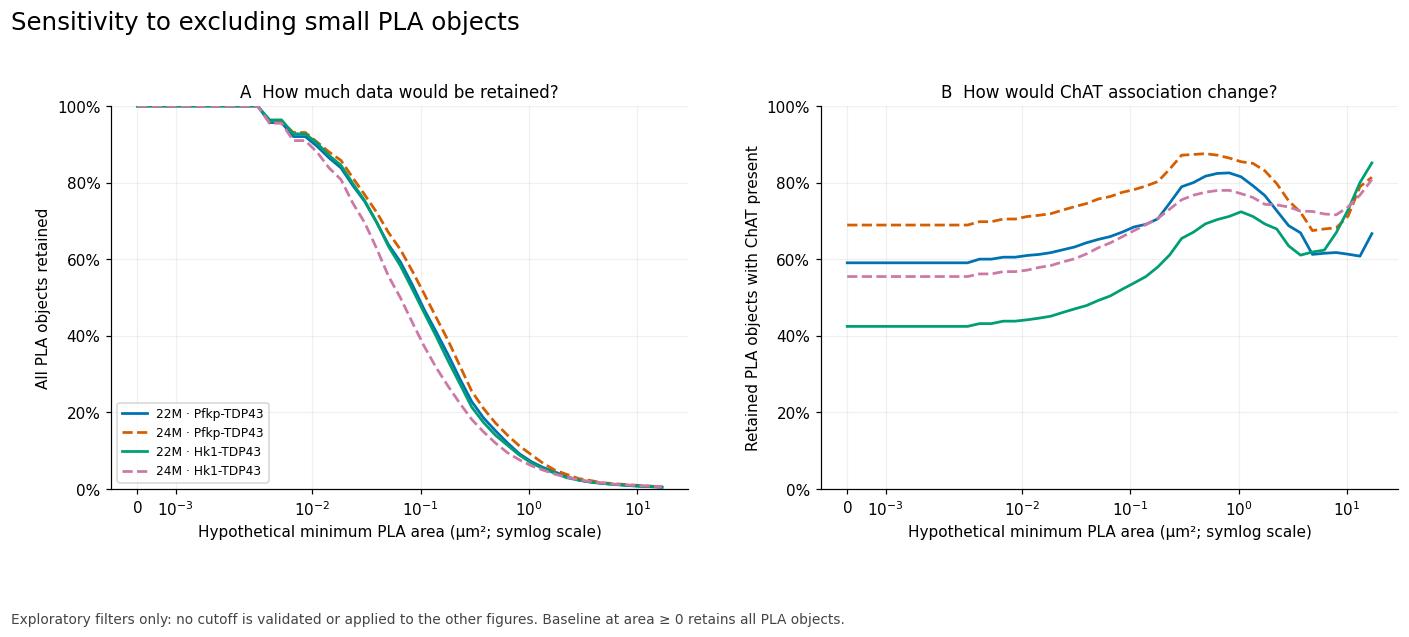

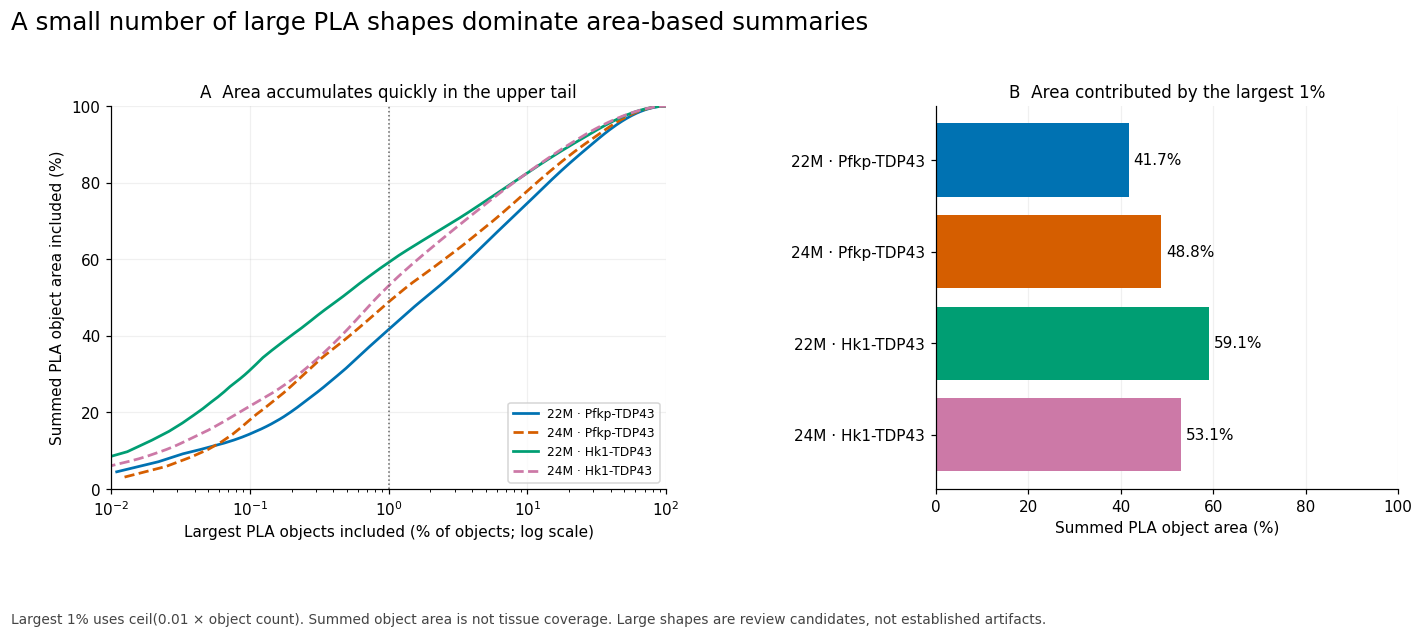

,job,region,object_type,object_id,area,overlap_pct,x,y
0,4594,22M_Pfkp-TDP43 PLA,ChAT,136913,2025.39820,0.000000,17539.0,7280.0
1,4594,22M_Pfkp-TDP43 PLA,ChAT,154098,2009.72130,0.000000,14019.0,8720.0
2,4594,22M_Pfkp-TDP43 PLA,ChAT,129418,2003.42420,0.000000,14659.0,6800.0
3,4594,22M_Pfkp-TDP43 PLA,ChAT,147343,2002.13840,0.000000,12739.0,8080.0
4,4594,22M_Pfkp-TDP43 PLA,ChAT,113941,1996.06090,0.000000,13379.0,6000.0
...,...,...,...,...,...,...,...,...
75,4597,24M_Hk1-TDP43 PLA,PLA,296095,159.64122,12.778455,42427.5,39439.5
76,4597,24M_Hk1-TDP43 PLA,PLA,21649,152.14304,42.891888,33382.0,28384.0
77,4597,24M_Hk1-TDP43 PLA,PLA,60169,151.25241,15.295142,40886.5,30145.0
78,4597,24M_Hk1-TDP43 PLA,PLA,109540,146.27559,8.794271,41575.0,32227.5


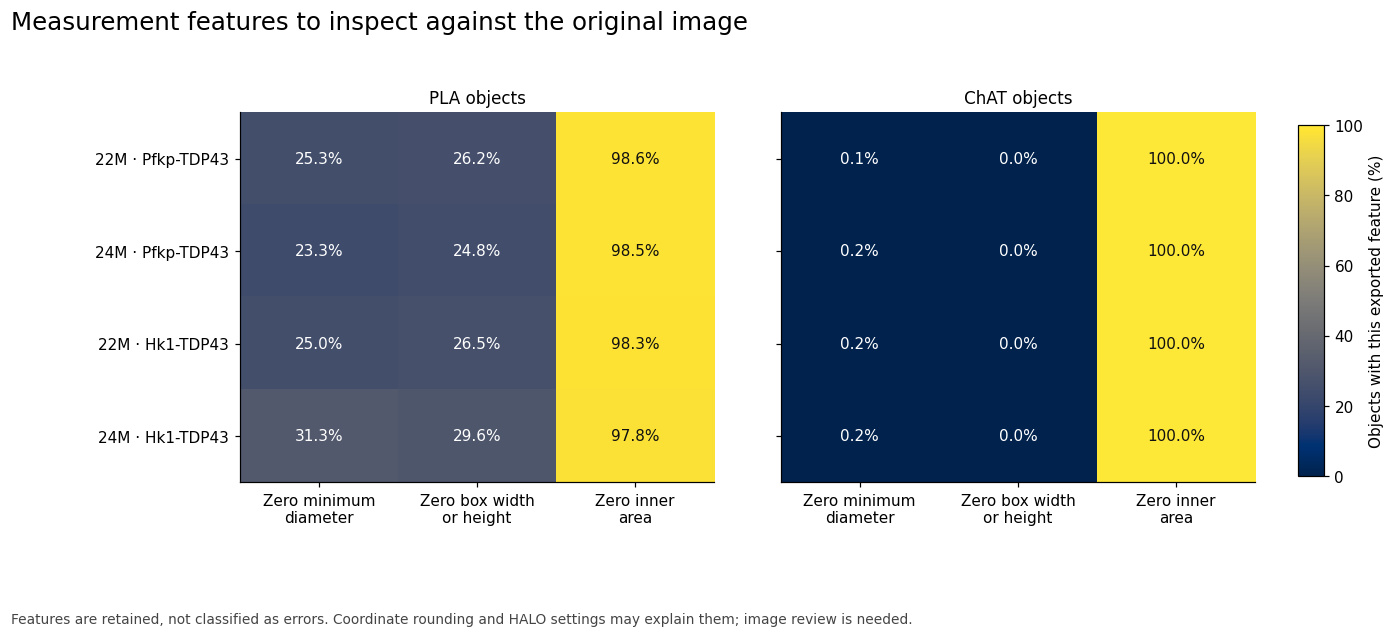

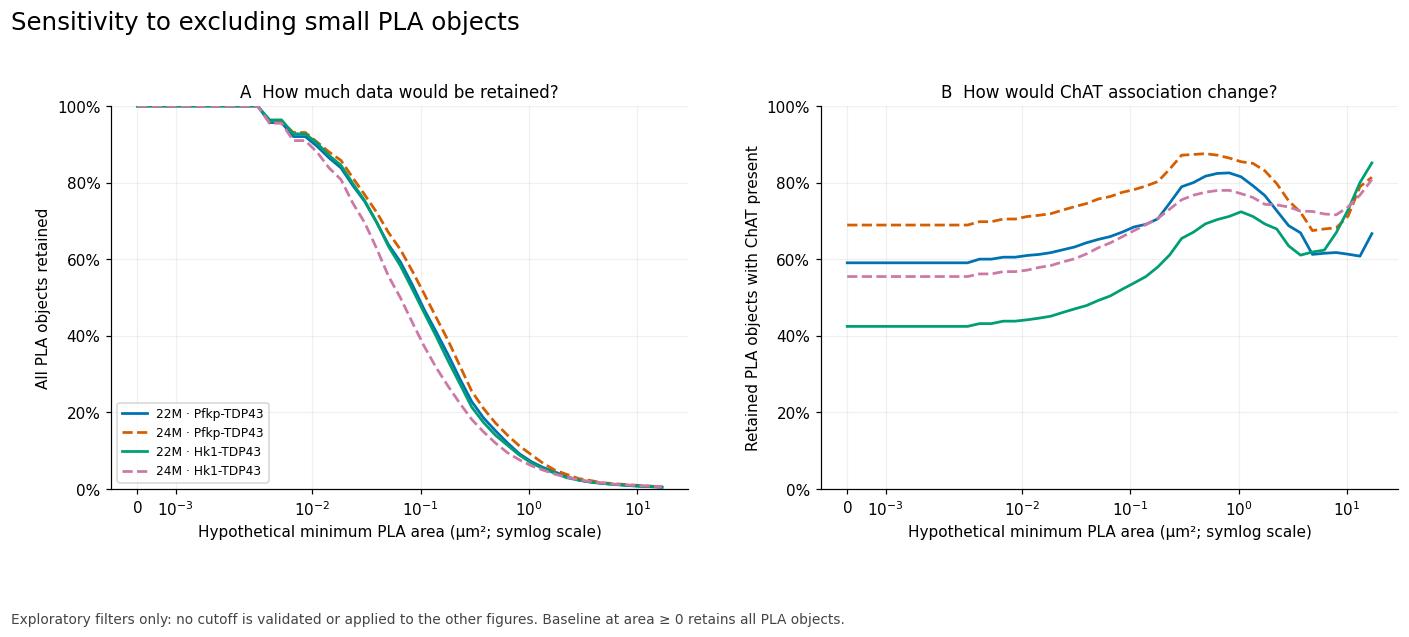

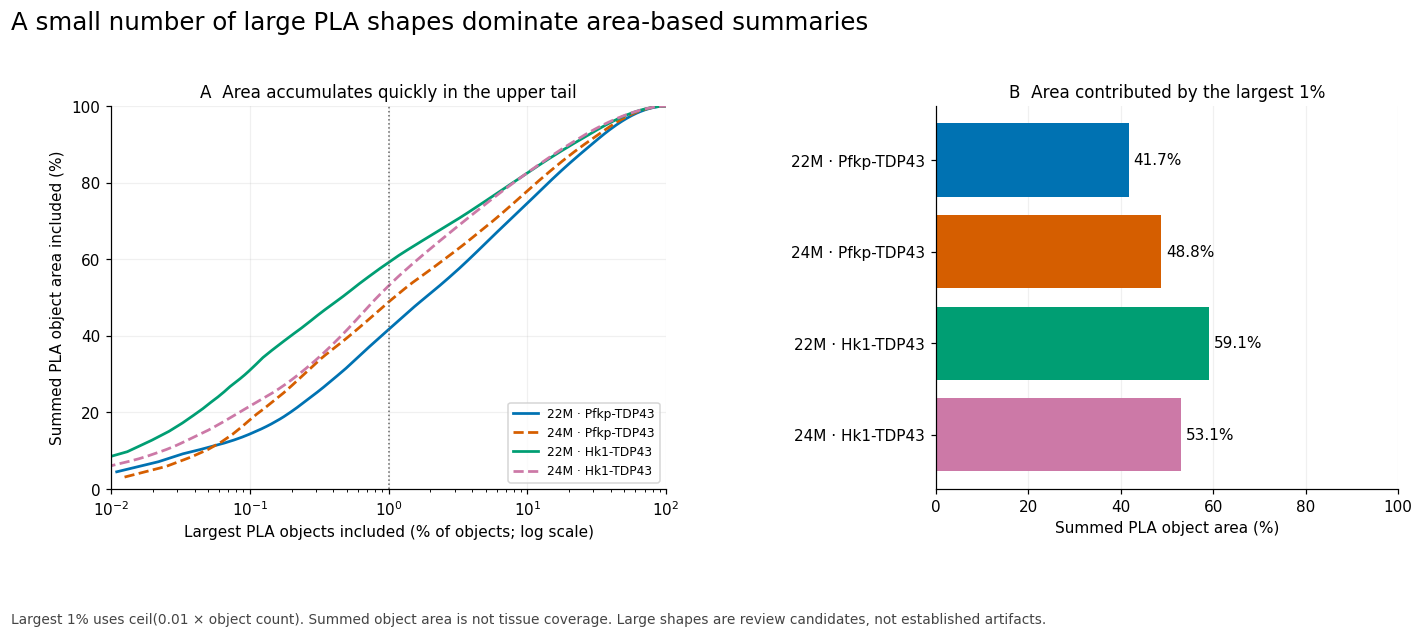

In [8]:
fig_qc, qc_table = measurement_qc(objects)
display(fig_qc)
save_figure(fig_qc, '10_measurement_quality_review', OUTPUT_ROOT)

fig_sensitivity, sensitivity_table = area_sensitivity(objects)
display(fig_sensitivity)
save_figure(fig_sensitivity, '11_area_filter_sensitivity', OUTPUT_ROOT)

fig_concentration, concentration_tables = area_concentration(objects)
display(fig_concentration)
save_figure(fig_concentration, '12_area_concentration', OUTPUT_ROOT)

display(top_objects(objects, n=10)[['job', 'region', 'object_type', 'object_id', 'area', 'overlap_pct', 'x', 'y']])

## 7. Save supporting data and provenance

The exports below contain the values behind the figures, so a reviewer can inspect counts without reverse-engineering pixels from a rendered chart. The raw source CSVs are not copied or altered.

In [10]:
tables = {
    'manifest': manifest,
    'summary': summary,
    'quality_control': qc,
    'overview': overview_table,
    'ecdf': ecdf_table,
    'overlap_composition': overlap_table,
    'size_overlap_bins': size_overlap_table,
    'area_sensitivity': sensitivity_table,
    'measurement_qc': qc_table,
    'area_concentration': concentration_tables['area_concentration'],
    'largest_one_percent': concentration_tables['largest_one_percent'],
    **spatial_tables,
}
tables = {name: frame for name, frame in tables.items() if frame is not None and not frame.empty}
xlsx_path = export_tables(tables, OUTPUT_ROOT, sources=manifest)
metadata_path = write_run_metadata(OUTPUT_ROOT, {
    'spatial_bin_width': SPATIAL_BIN_WIDTH,
    'minimum_raw_PLA_support': MIN_PLA_SUPPORT,
    'spatial_smoothing_sigma_bins': SPATIAL_SMOOTHING,
    'focus_job': FOCUS_JOB,
    'source_image_available': False,
}, manifest)
print(f"Figures: {OUTPUT_ROOT / 'figures'}")
print(f"Supporting tables: {xlsx_path}")
print(f"Run metadata: {metadata_path}")

Figures: /Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/figures
Supporting tables: /Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/visualization_data.xlsx
Run metadata: /Users/adambrewer/Desktop/Coding/Bio_Data_Analysis/outputs/run_metadata.json


## Scientific interpretation boundary

The figures can show differences in exported object counts, positions, size, intensity, and reported PLA-ChAT overlap across the four named regions. They cannot establish an age effect, disease effect, protein binding, cell number, tissue-normalized density, or animal-level statistical significance from these files alone.

For a true microscopy overlay and biologically interpretable comparisons, add a sample sheet, the original OME-TIFF plus metadata, analyzed ROI masks, HALO settings, cell/object assignments, and independent biological-replicate identities.